**Conditional GAN wtih Wasserstein Distance**

In [1]:
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

class Critic(nn.Module):
    def __init__(self, img_channels, num_classes, features, img_size=256):
        super().__init__()
        # 使用 Embedding 将类别转换为空间通道 (B, 1, H, W)
        self.label_embedding = nn.Embedding(num_classes, img_size * img_size)
        self.img_size = img_size
        
        # 输入通道为：图像通道 + 1个类别通道
        in_channels = img_channels + 1
        
        # WGAN-GP 的 Critic 中推荐不使用 BatchNorm/InstanceNorm，或仅用 LayerNorm/InstanceNorm(affine=False)
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1), # 256 -> 128
            nn.LeakyReLU(0.2),
            nn.Conv2d(features, features * 2, 4, 2, 1), # 128 -> 64
            nn.InstanceNorm2d(features * 2, affine=False),
            nn.LeakyReLU(0.2),
            nn.Conv2d(features * 2, features * 4, 4, 2, 1), # 64 -> 32
            nn.InstanceNorm2d(features * 4, affine=False),
            nn.LeakyReLU(0.2),
            nn.Conv2d(features * 4, features * 8, 4, 2, 1), # 32 -> 16
            nn.InstanceNorm2d(features * 8, affine=False),
            nn.LeakyReLU(0.2),
            nn.Conv2d(features * 8, features * 16, 4, 2, 1), # 16 -> 8
            nn.InstanceNorm2d(features * 16, affine=False),
            nn.LeakyReLU(0.2),
            nn.Conv2d(features * 16, 1, 8, 1, 0) # 8x8 -> 1x1 输出未经过激活标量
        )

    def forward(self, x, labels):
        # 动态将 label 展平并拼接为图像通道
        embedding = self.label_embedding(labels).view(-1, 1, self.img_size, self.img_size)
        x = torch.cat([x, embedding], dim=1)
        return self.net(x)

In [2]:
class Generator(nn.Module):
    def __init__(self, noise_channels, num_classes, img_channels, features):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, num_classes)
        
        # noise + one-hot/embedding vector
        in_dim = noise_channels + num_classes
        
        self.net = nn.Sequential(
            # input: (B, in_dim, 1, 1)
            self._block(in_dim, features * 32, 4, 1, 0),     # 1x1 -> 4x4
            self._block(features * 32, features * 16, 4, 2, 1), # 4x4 -> 8x8
            self._block(features * 16, features * 8, 4, 2, 1),  # 8x8 -> 16x16
            self._block(features * 8, features * 4, 4, 2, 1),   # 16x16 -> 32x32
            self._block(features * 4, features * 2, 4, 2, 1),   # 32x32 -> 64x64
            self._block(features * 2, features, 4, 2, 1),       # 64x64 -> 128x128
            nn.ConvTranspose2d(features, img_channels, 4, 2, 1),# 128x128 -> 256x256
            nn.Tanh()
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self, noise, labels):
        embedding = self.label_embedding(labels).unsqueeze(2).unsqueeze(3)
        x = torch.cat([noise, embedding], dim=1)
        return self.net(x)

Weight initialization and the gradient penalty function

In [3]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)    

In [4]:
z_dim = 100
img_channels = 3
features = 16
num_classes = 2 # 增加类别数定义

# Generator 参数：noise_channels, num_classes, img_channels, features
gen = Generator(z_dim, num_classes, img_channels, features).to(device)
# Critic 参数：img_channels, num_classes, features
critic = Critic(img_channels, num_classes, features).to(device)

weights_init(gen)
weights_init(critic)

In [5]:
lr = 0.0001
opt_gen = torch.optim.Adam(gen.parameters(), 
                         lr = lr, betas=(0.0, 0.9))
opt_critic = torch.optim.Adam(critic.parameters(), 
                         lr = lr, betas=(0.0, 0.9))

In [6]:
def GP(critic, real, fake, labels):
    B, C, H, W = real.shape
    alpha = torch.rand((B, 1, 1, 1)).repeat(1, C, H, W).to(device)
    interpolated_images = (real * alpha + fake * (1 - alpha)).requires_grad_(True)
    
    # 计算 critic 得分
    critic_scores = critic(interpolated_images, labels)
    
    # 求梯度
    gradient = torch.autograd.grad(
        inputs=interpolated_images,
        outputs=critic_scores,
        grad_outputs=torch.ones_like(critic_scores),
        create_graph=True,
        retain_graph=True
    )[0]
    
    gradient = gradient.view(gradient.shape[0], -1)
    gradient_norm = gradient.norm(2, dim=1)
    gp = torch.mean((gradient_norm - 1) ** 2)
    return gp

**Train conditional GAN**

Adding labels

In [7]:
import torchvision.transforms as T
import torchvision

batch_size=16
imgsz=256
transform=T.Compose([
    T.Resize((imgsz,imgsz)),
    T.ToTensor(),
    T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])])      
data_set=torchvision.datasets.ImageFolder(
    root=r"D:\DeepLearning\DataSet\Figure\hotdog\train",
    transform=transform) 

In [8]:
newdata=[]
for i,(img,label) in enumerate(data_set):
    onehot=torch.zeros((2))
    onehot[label]=1
    channels=torch.zeros((2,imgsz,imgsz))
    if label==0:
        channels[0,:,:]=1
    else:
        channels[1,:,:]=1    
    img_and_label=torch.cat([img,channels],dim=0)    
    newdata.append((img,label,onehot,img_and_label))

In [9]:
data_loader=torch.utils.data.DataLoader(
    newdata,batch_size=batch_size,shuffle=True)

In [10]:
def plot_epoch(epoch):
    # test images with label 0
    noise = torch.randn(32, z_dim, 1, 1).to(device)
    labels = torch.zeros(32, dtype=torch.long).to(device) # 直接使用整数标签 0
    fake = gen(noise, labels).cpu().detach()
    
    fig = plt.figure(figsize=(20, 10), dpi=100)
    for i in range(32):
        ax = plt.subplot(4, 8, i + 1)
        img = (fake[i] / 2 + 0.5).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.xticks([]); plt.yticks([])
    plt.subplots_adjust(hspace=-0.6)
    # plt.savefig(f"files/glasses/G{epoch}.png")
    plt.show() 
    
    # test images with label 1
    noise = torch.randn(32, z_dim, 1, 1).to(device)
    labels = torch.ones(32, dtype=torch.long).to(device) # 直接使用整数标签 1
    fake = gen(noise, labels).cpu().detach()
    
    fig = plt.figure(figsize=(20, 10), dpi=100)
    for i in range(32):
        ax = plt.subplot(4, 8, i + 1)
        img = (fake[i] / 2 + 0.5).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.xticks([]); plt.yticks([])
    plt.subplots_adjust(hspace=-0.6)
    plt.show()

In [11]:
def train_batch(real_imgs, labels):
    real_imgs = real_imgs.to(device)
    labels = labels.to(device)
    B = real_imgs.shape[0]

    # 1. 训练 Critic 5 次
    for _ in range(5):
        noise = torch.randn(B, z_dim, 1, 1, device=device)
        # 注意：一定要 detach() 生成的假图像，切断 G 的梯度流，防止内存泄漏！
        fake_imgs = gen(noise, labels).detach() 
        
        critic_real = critic(real_imgs, labels).reshape(-1)
        critic_fake = critic(fake_imgs, labels).reshape(-1)
        gp = GP(critic, real_imgs, fake_imgs, labels)
        
        loss_critic = -(torch.mean(critic_real) - torch.mean(critic_fake)) + 10 * gp
        
        opt_critic.zero_grad()
        loss_critic.backward() # 无需 retain_graph=True
        opt_critic.step()

    # 2. 训练 Generator 1 次
    noise = torch.randn(B, z_dim, 1, 1, device=device)
    gen_fake_imgs = gen(noise, labels)
    gen_scores = critic(gen_fake_imgs, labels).reshape(-1)
    
    loss_gen = -torch.mean(gen_scores)
    
    opt_gen.zero_grad()
    loss_gen.backward()
    opt_gen.step()

    return loss_critic.item(), loss_gen.item()

In [12]:
import matplotlib.pyplot as plt

In [ ]:
for epoch in range(1, 101):
    closs = 0
    gloss = 0
    # 注意：这里我们提取第一个(真实图像)和第二个(类别索引)，忽略你自己拼接的后两项
    for img, label, _, _ in data_loader:
        loss_critic, loss_gen = train_batch(img, label)
        closs += loss_critic / len(data_loader)
        gloss += loss_gen / len(data_loader)
        
    print(f"at epoch {epoch}, critic loss: {closs}, generator loss {gloss}")

torch.save(gen.state_dict(), 'files/cgan.pth')

Select images with or without feature

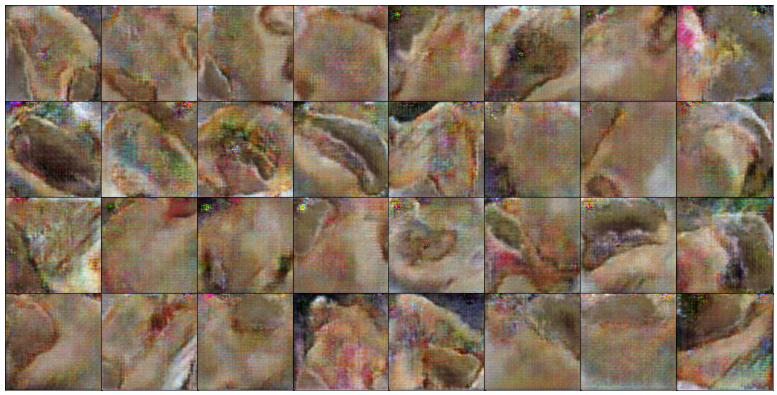

In [17]:
torch.manual_seed(0)


class CheckpointGenerator(nn.Module):
    def __init__(self, noise_channels, num_classes, img_channels, features):
        super().__init__()
        embedding_dim = 64
        self.label_embedding = nn.Embedding(num_classes, embedding_dim)

        in_dim = noise_channels + embedding_dim

        self.net = nn.Sequential(
            self._block(in_dim, features * 32, 4, 1, 0),
            self._block(features * 32, features * 16, 4, 2, 1),
            self._block(features * 16, features * 8, 4, 2, 1),
            self._block(features * 8, features * 4, 4, 2, 1),
            self._block(features * 4, features * 2, 4, 2, 1),
            self._block(features * 2, features, 4, 2, 1),
            nn.ConvTranspose2d(features, img_channels, 4, 2, 1),
            nn.Tanh()
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                bias=False
            ),
            nn.BatchNorm2d(
                out_channels,
                track_running_stats=False
            ),
            nn.ReLU()
        )

    def forward(self, noise, labels):
        embedding = self.label_embedding(labels).unsqueeze(2).unsqueeze(3)
        x = torch.cat([noise, embedding], dim=1)
        return self.net(x)


generator_model = CheckpointGenerator(
    noise_channels=z_dim,
    num_classes=num_classes,
    img_channels=img_channels,
    features=features
).to(device)

generator_model.load_state_dict(torch.load(
    "files/cgan_2.pth",
    map_location=device,
    weights_only=True
))


class GeneratorAdapter(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, noise_and_labels):
        noise = noise_and_labels[:, :z_dim]
        labels = noise_and_labels[:, z_dim:].flatten(1).argmax(dim=1).long()
        return self.model(noise, labels)


generator = GeneratorAdapter(generator_model).to(device)
generator.eval()

noise_g = torch.randn(32, z_dim, 1, 1)
labels_g = torch.zeros(32, 2, 1, 1)
labels_g[:, 0, :, :] = 1
noise_and_labels = torch.cat([noise_g, labels_g], dim=1).to(device)

with torch.no_grad():
    fake = generator(noise_and_labels)

plt.figure(figsize=(20, 10), dpi=50)
for i in range(32):
    ax = plt.subplot(4, 8, i + 1)
    img = (fake[i].cpu() / 2 + 0.5).permute(1, 2, 0)
    plt.imshow(img.numpy())
    plt.xticks([])
    plt.yticks([])

plt.subplots_adjust(wspace=-0.08, hspace=-0.01)
plt.show()

In [18]:
z_male_g=noise_g[0]
z_female_g=noise_g[14]

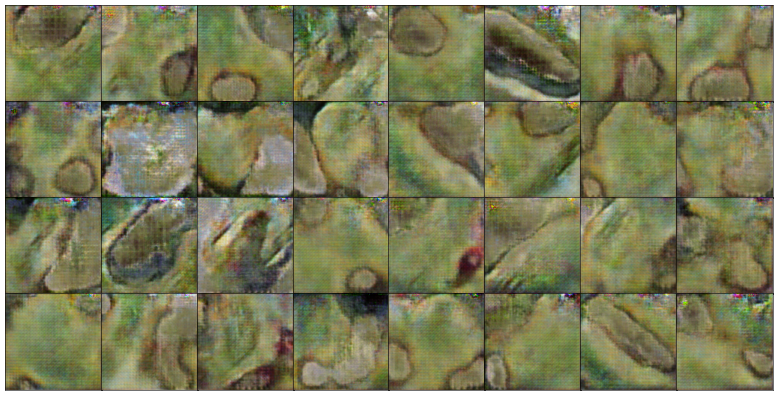

In [19]:
noise_ng = torch.randn(32, z_dim, 1, 1)
labels_ng = torch.zeros(32, 2, 1, 1)
labels_ng[:,1,:,:]=1
noise_and_labels=torch.cat([noise_ng,labels_ng],dim=1).to(device)
fake=generator(noise_and_labels).cpu().detach()
plt.figure(figsize=(20,10),dpi=50)
for i in range(32):
    ax = plt.subplot(4, 8, i + 1)
    img=(fake.cpu().detach()[i]/2+0.5).permute(1,2,0)
    plt.imshow(img.numpy())#.repeat(4,axis=0).repeat(4,axis=1))
    plt.xticks([])
    plt.yticks([])
plt.subplots_adjust(wspace=-0.08,hspace=-0.01)
plt.show()

In [20]:
z_male_ng=noise_ng[8]
z_female_ng=noise_ng[31]

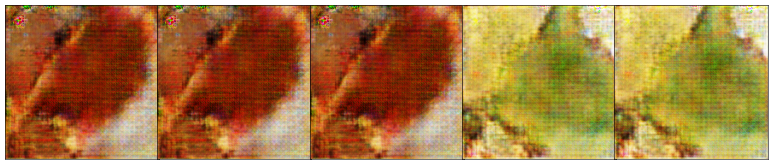

In [21]:
weights=[0,0.25,0.5,0.75,1]
plt.figure(figsize=(20,4),dpi=50)
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    # change the value of z
    label=weights[i]*labels_ng[0]+(1-weights[i])*labels_g[0]
    noise_and_labels=torch.cat(
        [z_female_g.reshape(1, z_dim, 1, 1),
         label.reshape(1, 2, 1, 1)],dim=1).to(device)    
    fake=generator(noise_and_labels).cpu().detach()    
    img=(fake[0]/2+0.5).permute(1,2,0)
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
plt.subplots_adjust(wspace=-0.08,hspace=-0.01)
plt.show()